# Exploratory Plots for H1 Outcomes

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

## Load data files
- **Interval A**: Content from 24 days before exposure to 12 days before exposure
- **Interval B**: Content from 12 days before exposure to exposure
- **Interval C**: Content from exposure to 12 days after exposure

Looks something like:

|---A---|---B---|||---C---|

For each interval, the respective data file contains the outcomes per each user (aggregated for that interval).
For example, a user's total AI watch time reflects their total watch time for that interval of 12 days.

In [2]:
A = pd.read_csv("../data/pre_history_a_results.csv")
B = pd.read_csv("../data/pre_history_b_results.csv")
C = pd.read_csv("../data/post_history_c_results.csv")

A["period"] = "A"
B["period"] = "B"
C["period"] = "C"

df = pd.concat([A, B, C], ignore_index=True)
df.head()

,participant_id,assignment,total_videos,total_adjusted_videos,playlist_videos,all_ai_videos,ai_adjusted_videos,share_ai_adjusted_videos,total_watch_time,total_adjusted_watch_time,playlist_watch_time,all_ai_watch_time,ai_adjusted_watch_time,share_ai_adjusted_watch_time,period
0,fdb5784192ad35049dc9bfacc19b6a7b9333d974f15b51...,Control,61,61,0,0,0,0.000000,58691.947,58691.947,0.0,0.0,0.0,0.000000,A
1,5b7ab1cc1fdece4fedb8fe7b6582e0d3b2adbac8dce18d...,Control,28,28,0,1,1,0.035714,55516.324,55516.324,0.0,12565.0,12565.0,0.226330,A
2,55994a723434cbfb0845d55bfe4c5dde74cd5677026912...,Control,53,53,0,0,0,0.000000,13277.939,13277.939,0.0,0.0,0.0,0.000000,A
3,a155d37a45ba76adb6582c15757bb42369bfdbcc45e96f...,Treatment,43,43,0,0,0,0.000000,42619.747,42619.747,0.0,0.0,0.0,0.000000,A
4,7ae9ec4376f913bd5b2adf7278894749f7d3a85830bada...,Treatment,172,172,0,1,1,0.005814,50157.460,50157.460,0.0,16.0,16.0,0.000319,A


In [3]:
# ── Prepare propensity matched dataset ──────────────────────────────────────────────────────────
matched_ids = pd.read_csv("../data/propensity_matched_ids.csv")["PROLIFIC_PID"]
df_filtered = df[df["participant_id"].isin(matched_ids)].copy()
print("Total rows:", len(df_filtered)) # expect this to be 3*228=684
print("Unique participants:", df_filtered["participant_id"].nunique()) # expect this to be 228

Total rows: 684
Unique participants: 228


## Interval Summary Metrics
For each interval, compute the mean and median of each of the following outcomes across each condition:
- Total count of videos
- Count of AI videos
- Share of AI videos
- Total watch time
- AI watch time
- Share of AI watch time

### Summary Results

In [4]:
# ── Compute on full dataset ──────────────────────────────────────────────────────────
outcomes = [
    "total_adjusted_videos",
    "ai_adjusted_videos",
    "share_ai_adjusted_videos",
    "total_adjusted_watch_time",
    "ai_adjusted_watch_time",
    "share_ai_adjusted_watch_time"
]

summary = (
    df
    .groupby(["period", "assignment"])[outcomes]
    .agg(["mean", "median", "std", "count"])
)

# compute CIs so that we can include them in our plots
for outcome in outcomes:
    summary[(outcome, "ci")] = (
        1.96 * summary[(outcome, "std")]
        / np.sqrt(summary[(outcome, "count")])
    )

In [5]:
print(summary["total_adjusted_videos"])

                         mean  median         std  count          ci
period assignment                                                   
A      Control     586.274074   275.0  888.509438    135  149.882605
       Treatment   619.265060   275.5  878.249065    166  133.604081
B      Control     533.459259   235.0  836.031928    135  141.030177
       Treatment   550.018072   218.0  782.708495    166  119.069923
C      Control     627.488889   295.0  993.074217    135  167.521631
       Treatment   630.945783   257.0  963.536078    166  146.578410


In [6]:
print(summary["total_adjusted_watch_time"])

                            mean       median           std  count  \
period assignment                                                    
A      Control     154634.405170  108713.3860  1.398091e+05    135   
       Treatment   177622.358645  142391.9770  1.584969e+05    166   
B      Control     180204.406852   87331.3430  5.802686e+05    135   
       Treatment   132881.679229  102699.8040  1.261259e+05    166   
C      Control     692496.943319  117348.0000  5.455037e+06    135   
       Treatment   166977.895855  123711.1605  1.636776e+05    166   

                              ci  
period assignment                 
A      Control      23584.395084  
       Treatment    24111.425478  
B      Control      97885.468302  
       Treatment    19186.961431  
C      Control     920209.913191  
       Treatment    24899.529705  


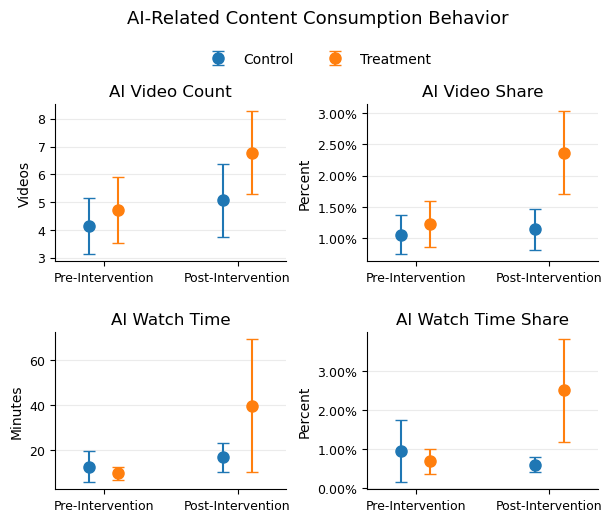

In [7]:
# ── Visualize for full dataset ──────────────────────────────────────────────────────────

period_order = ["B", "C"]
period_labels = ["Pre-Intervention", "Post-Intervention"]

figures = [
    ("ai_adjusted_videos", "AI Video Count", "count"),
    ("share_ai_adjusted_videos", "AI Video Share", "share"),
    ("ai_adjusted_watch_time", "AI Watch Time", "time"),
    ("share_ai_adjusted_watch_time", "AI Watch Time Share", "share"),
]

conditions = list(
    summary.index.get_level_values("assignment").unique()
)

# Smaller overall canvas so text/markers stay larger after LaTeX scaling
fig, axes = plt.subplots(2, 2, figsize=(7, 5))
axes = axes.flatten()

# Keep conditions close together within each period
offsets = np.linspace(-0.06, 0.06, len(conditions))

# Compress distance between pre and post
x = np.array([0, 0.55])

for ax, (outcome, title, outcome_type) in zip(axes, figures):

    for offset, condition in zip(offsets, conditions):

        means = np.array([
            summary.loc[(period, condition), (outcome, "mean")]
            for period in period_order
        ], dtype=float)

        intervals = np.array([
            summary.loc[(period, condition), (outcome, "ci")]
            for period in period_order
        ], dtype=float)

        # Convert units for easier interpretation
        if outcome_type == "share":
            means *= 100
            intervals *= 100
        elif outcome_type == "time":
            means /= 60
            intervals /= 60

        ax.errorbar(
            x + offset,
            means,
            yerr=intervals,
            fmt="o",
            markersize=8,
            capsize=4,
            elinewidth=1.5,
            label=condition,
        )

    ax.set_title(
        title,
        fontsize=12,
        pad=6,
    )

    ax.set_xticks(x)
    ax.set_xticklabels(
        period_labels,
        fontsize=9,
    )

    # Tighten horizontal plotting range
    ax.set_xlim(-0.20, 0.75)

    ax.tick_params(
        axis="y",
        labelsize=9,
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.grid(
        axis="y",
        alpha=0.25,
    )

    if outcome_type == "share":
        ax.set_ylabel(
            "Percent",
            fontsize=10,
        )
        ax.yaxis.set_major_formatter(
            mtick.PercentFormatter()
        )

    elif outcome_type == "time":
        ax.set_ylabel(
            "Minutes",
            fontsize=10,
        )

    else:
        ax.set_ylabel(
            "Videos",
            fontsize=10,
        )

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=len(conditions),
    frameon=False,
    fontsize=10,
    bbox_to_anchor=(0.5, 1.01),
)

fig.suptitle(
    "AI-Related Content Consumption Behavior",
    fontsize=13,
    y=1.07,
)

plt.subplots_adjust(
    wspace=0.35,
    hspace=0.45,
)

plt.savefig(
    "../figures/h1_exploratory_plots_full.pdf",
    format="pdf",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [8]:
# ── Compute on propensity weighted dataset ──────────────────────────────────────────────────────────
outcomes = [
    "total_adjusted_videos",
    "ai_adjusted_videos",
    "share_ai_adjusted_videos",
    "total_adjusted_watch_time",
    "ai_adjusted_watch_time",
    "share_ai_adjusted_watch_time"
]


def weighted_median(x, w):
    order = np.argsort(x)
    x = np.asarray(x)[order]
    w = np.asarray(w)[order]

    cutoff = 0.5 * w.sum()
    return x[np.cumsum(w) >= cutoff][0]


def weighted_summary(group, outcome):
    tmp = group[[outcome, "stabilized_weight"]].dropna()

    x = tmp[outcome].to_numpy(dtype=float)
    w = tmp["stabilized_weight"].to_numpy(dtype=float)

    # weighted mean
    mean = np.average(x, weights=w)

    # weighted population variance / SD
    var = np.average((x - mean) ** 2, weights=w)
    sd = np.sqrt(var)

    # weighted median
    median = weighted_median(x, w)

    # actual number of observations
    count = len(x)

    # effective sample size
    n_eff = (w.sum() ** 2) / np.sum(w ** 2)

    # approximate SE and 95% CI half-width
    se = sd / np.sqrt(n_eff)
    ci = 1.96 * se

    return pd.Series({
        "mean": mean,
        "median": median,
        "std": sd,
        "count": count,
        "n_eff": n_eff,
        "ci": ci
    })

In [9]:
weights_df = pd.read_csv("../data/full_data_with_propensity_scores.csv")[["PROLIFIC_PID", "propensity_score", "stabilized_weight"]]
df_weighted = df.merge(
    weights_df,
    left_on="participant_id",
    right_on="PROLIFIC_PID",
    how="inner"
)

In [10]:
results = []

for (period, assignment), group in df_weighted.groupby(["period", "assignment"]):
    for outcome in outcomes:
        stats_out = weighted_summary(group, outcome)

        results.append({
            "period": period,
            "assignment": assignment,
            "outcome": outcome,
            **stats_out.to_dict()
        })

weighted_summary_df = pd.DataFrame(results)
summary_weighted = weighted_summary_df.pivot(
    index=["period", "assignment"],
    columns="outcome",
    values=["mean", "median", "std", "count", "n_eff", "ci"]
)

In [11]:
print(summary_weighted["mean"]["total_adjusted_videos"])

period  assignment
A       Control       584.821795
        Treatment     616.855329
B       Control       551.736185
        Treatment     556.136474
C       Control       646.787630
        Treatment     655.217900
Name: total_adjusted_videos, dtype: float64


In [12]:
print(summary_weighted["median"]["total_adjusted_watch_time"])

period  assignment
A       Control       108713.386
        Treatment     142210.866
B       Control        86750.709
        Treatment     113146.101
C       Control       116057.017
        Treatment     125935.498
Name: total_adjusted_watch_time, dtype: float64


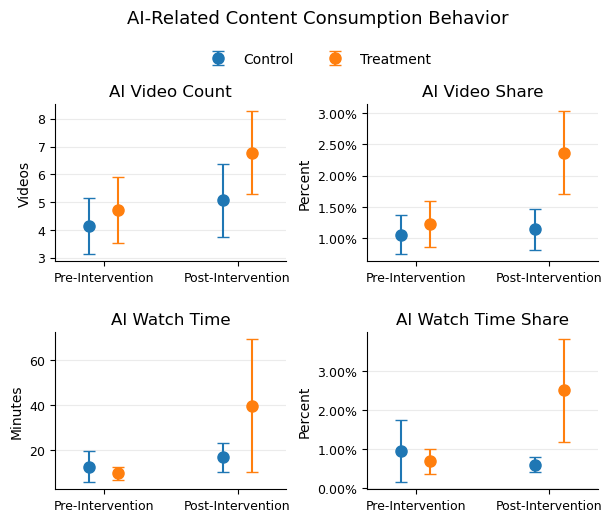

In [13]:
# ── Visualize for weighted dataset ──────────────────────────────────────────────────────────

period_order = ["B", "C"]
period_labels = ["Pre-Intervention", "Post-Intervention"]

figures = [
    ("ai_adjusted_videos", "AI Video Count", "count"),
    ("share_ai_adjusted_videos", "AI Video Share", "share"),
    ("ai_adjusted_watch_time", "AI Watch Time", "time"),
    ("share_ai_adjusted_watch_time", "AI Watch Time Share", "share"),
]

conditions = list(
    summary_weighted.index.get_level_values("assignment").unique()
)

# Smaller overall canvas so text/markers stay larger after LaTeX scaling
fig, axes = plt.subplots(2, 2, figsize=(7, 5))
axes = axes.flatten()

# Keep conditions close together within each period
offsets = np.linspace(-0.06, 0.06, len(conditions))

# Compress distance between pre and post
x = np.array([0, 0.55])

for ax, (outcome, title, outcome_type) in zip(axes, figures):

    for offset, condition in zip(offsets, conditions):

        means = np.array([
            summary.loc[(period, condition), (outcome, "mean")]
            for period in period_order
        ], dtype=float)

        intervals = np.array([
            summary.loc[(period, condition), (outcome, "ci")]
            for period in period_order
        ], dtype=float)

        # Convert units for easier interpretation
        if outcome_type == "share":
            means *= 100
            intervals *= 100
        elif outcome_type == "time":
            means /= 60
            intervals /= 60

        ax.errorbar(
            x + offset,
            means,
            yerr=intervals,
            fmt="o",
            markersize=8,
            capsize=4,
            elinewidth=1.5,
            label=condition,
        )

    ax.set_title(
        title,
        fontsize=12,
        pad=6,
    )

    ax.set_xticks(x)
    ax.set_xticklabels(
        period_labels,
        fontsize=9,
    )

    # Tighten horizontal plotting range
    ax.set_xlim(-0.20, 0.75)

    ax.tick_params(
        axis="y",
        labelsize=9,
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.grid(
        axis="y",
        alpha=0.25,
    )

    if outcome_type == "share":
        ax.set_ylabel(
            "Percent",
            fontsize=10,
        )
        ax.yaxis.set_major_formatter(
            mtick.PercentFormatter()
        )

    elif outcome_type == "time":
        ax.set_ylabel(
            "Minutes",
            fontsize=10,
        )

    else:
        ax.set_ylabel(
            "Videos",
            fontsize=10,
        )

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=len(conditions),
    frameon=False,
    fontsize=10,
    bbox_to_anchor=(0.5, 1.01),
)

fig.suptitle(
    "AI-Related Content Consumption Behavior",
    fontsize=13,
    y=1.07,
)

plt.subplots_adjust(
    wspace=0.35,
    hspace=0.45,
)

plt.savefig(
    "../figures/h1_exploratory_plots_weighted.pdf",
    format="pdf",
    dpi=300,
    bbox_inches="tight",
)

plt.show()